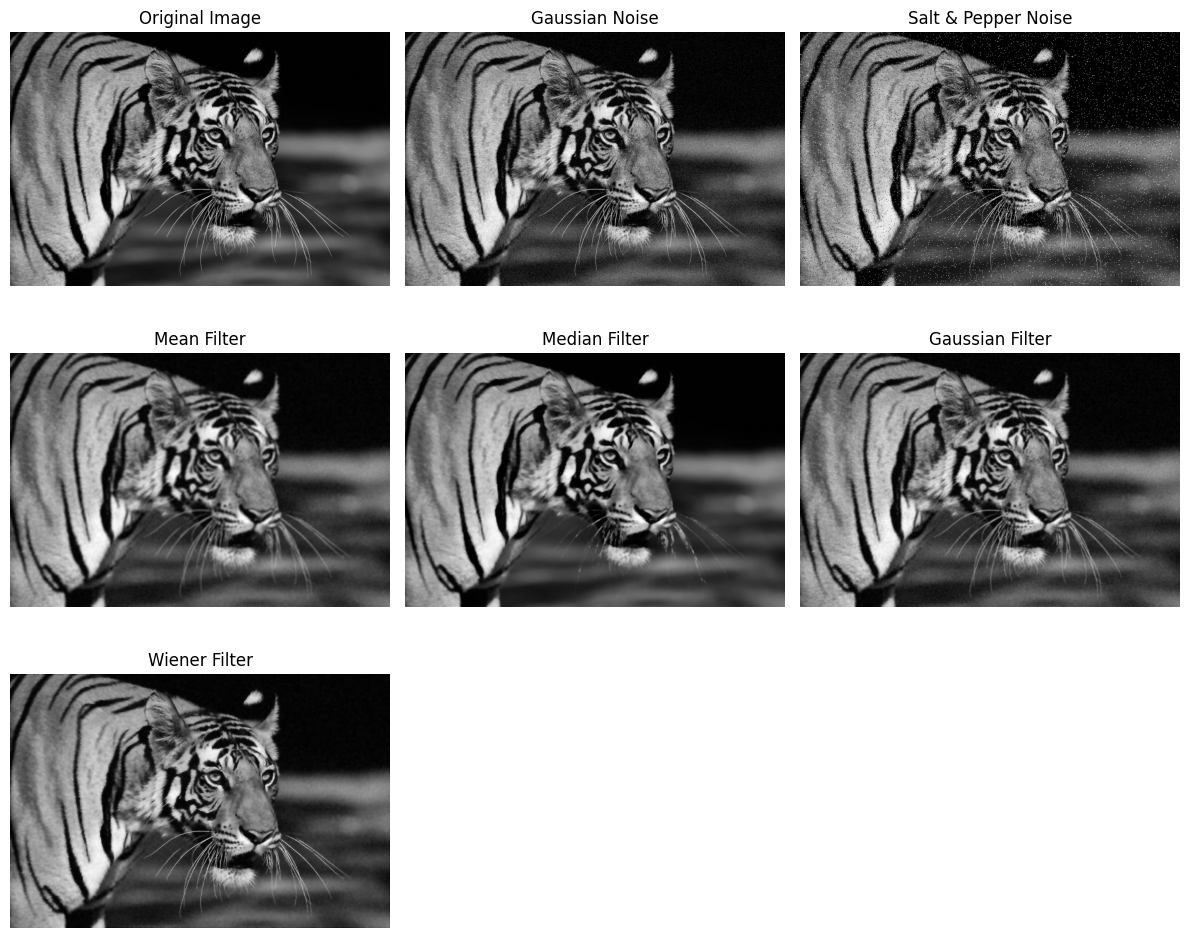

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener

image = cv2.imread('/content/test_image.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

image = image / 255.0

mean = 0
sigma = 0.05
gaussian_noise = np.random.normal(mean, sigma, image.shape)
noisy_gaussian = image + gaussian_noise
noisy_gaussian = np.clip(noisy_gaussian, 0, 1)

salt_prob = 0.02
pepper_prob = 0.02

noisy_sp = np.copy(image)
num_salt = np.ceil(salt_prob * image.size)
coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
noisy_sp[coords[0], coords[1]] = 1

num_pepper = np.ceil(pepper_prob * image.size)
coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
noisy_sp[coords[0], coords[1]] = 0

mean_filtered = cv2.blur(noisy_gaussian, (5, 5))

median_filtered = cv2.medianBlur((noisy_sp * 255).astype(np.uint8), 5)

gaussian_filtered = cv2.GaussianBlur(noisy_gaussian, (5, 5), 0)

wiener_filtered = wiener(noisy_gaussian, (5, 5))

plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(noisy_gaussian, cmap='gray')
plt.title("Gaussian Noise")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(noisy_sp, cmap='gray')
plt.title("Salt & Pepper Noise")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(mean_filtered, cmap='gray')
plt.title("Mean Filter")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(median_filtered, cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(gaussian_filtered, cmap='gray')
plt.title("Gaussian Filter")
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(wiener_filtered, cmap='gray')
plt.title("Wiener Filter")
plt.axis('off')

plt.tight_layout()
plt.show()